<h1 style="color: rgb(255,98,0)">OSA Growth Intelligence Model</h1>

<h2 style="color: rgb(255,98,0)">Projenin Kapsamı</h2>

OSA Growth Intelligence Modeli, bankanın 2026 yıl sonu hedefi olan 120 Milyar TL bakiye büyüklüğüne ulaşabilmesi için geliştirilmiş bir karar destek sistemidir. Projenin çıkış noktası, Turuncu Hesap faiz kararlarını sezgisel yaklaşımdan çıkarıp veri odaklı bir yapıya taşımaktır. Model, haftalık veya aylık karar döngülerinde yöneticilere "Bu dönem faizi ne yapmalıyız?" sorusuna somut ve sayısal cevaplar sunmayı hedeflemektedir.

Bu notebook, söz konusu sistemin tahmin motorunu barındırmaktadır. Tahmin edilen değişken **Netflow Rate** olup Inflow Rate − Outflow Rate farkından oluşmaktadır. Bir sonraki haftanın net para akışını öngörebilmek, faiz optimizasyonu ve senaryo analizleri için zorunlu ön koşuldur.

<h2 style="color: rgb(255,98,0)">Mevcut Durum ve İş Problemi</h2>

Turuncu Hesap faiz kararları bugüne kadar ağırlıklı olarak sezgisel yaklaşım ve rakip takibi ile alınmıştır. Bu geleneksel yapı, bankanın uzun vadeli hedeflerine ulaşmasında beş kritik risk oluşturmaktadır:

* **Reaktif Karar Alma:** Rakip faiz artırdığında "biz de artıralım" refleksiyle hareket edilmektedir. Banka piyasada oyun kurucu değil takipçi konumuna düşmekte, proaktif bilanço yönetimi yapılamamaktadır.

* **Hedef Belirsizliği:** "120 Milyar TL'ye ulaşmak için bu hafta tam olarak ne yapmalıyız?" sorusunun sayısal bir cevabı bulunmamaktadır. Hedefin ne kadar gerisinde veya önünde olunduğu matematiksel olarak belirsizdir ve yıl sonunda sürprizle karşılaşma riski taşımaktadır.

* **Maliyet Optimizasyonu Eksikliği:** Hedefi tutturacak en düşük (optimal) faiz oranı bilinmediğinden, yönetici emin olmak adına gereksiz yüksek faiz verme eğilimindedir. Örneğin faizi 46 yaparak hedef tutabilecekken 47 verilmesi, yıllık milyonlarca TL fazla maliyet anlamına gelmektedir.

* **Kişi Bağımlılığı:** Mevcut süreçler büyük ölçüde manuel Excel tabloları ve belirli kişilerin uzmanlığına dayanmaktadır. Kurumsal hafıza oluşamamakta, karar verici uzmanın bulunmadığı dönemlerde süreç kalitesi düşmektedir.

* **Senaryo Eksikliği:** "Faizi 50 yaparsak ne olur?" veya "Kur %10 artarsa mevduat nasıl etkilenir?" gibi "Ya böyle olursa?" sorularına mevcut yapıda yanıt verilememektedir.

<h2 style="color: rgb(255,98,0)">Model Mimarisi ve Veri Katmanları</h2>

Model, tahmin üretmek için üç veri katmanından beslenmektedir:

- **Banka İçi (Internal) Veriler:** Ortalama vadeli bakiye, yeni müşteri sayısı (NTB), hesap açılış hacmi, hoşgeldin kampanyası dönüşümü gibi doğrudan bankadan gelen operasyonel metrikler.
- **Banka Dışı (External/Makro) Veriler:** TLREF, TCMB politika faizi, CDS, kur oynaklığı, VIX, tüketim endeksleri ve enflasyon beklentileri gibi piyasa göstergeleri.
- **Çapraz (Interaction) Değişkenler:** İç ve dış verinin birbirine göre anlamlı kombinasyonları — rekabetçi faiz farkı × yeni müşteri, TLREF × kur oynaklığı gibi etkileşim terimleri.

Değişken seçimi (feature selection) rolling yapıya taşınmış olup model her hafta yalnızca o ana kadar gördüğü veriyle çalışmakta, gelecekten bilgi sızması (leakage) engellenmiş durumdadır.

<h2 style="color: rgb(255,98,0)">Kütüphanelerin Kurulumu</h2>

Modelin çalışması için gerekli olan veri işleme, istatistik, makine öğrenmesi ve görselleştirme kütüphaneleri burada yüklenmektedir.

In [10]:
# Jupyter/VSCode çıktı alanındaki kaydırma sınırını kaldır (uzun tablolar kesilmesin)
from IPython.display import display, HTML
display(HTML("<style>div.output_scroll { height: auto !important; max-height: none !important; }</style>"))

# Pandas tablo görüntüleme ayarları (satır, sütun ve genişlik limitleri kaldırılıyor)
import pandas as pd
pd.set_option('display.max_rows', 999)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 999)

# Veri işleme ve sayısal hesaplama
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistik ve korelasyon testleri
from scipy import stats
from scipy.stats import spearmanr

# Makine öğrenmesi: model, ölçekleme, değerlendirme metrikleri
from sklearn.linear_model import RidgeCV                    # Çapraz doğrulamalı Ridge regresyon
from sklearn.model_selection import TimeSeriesSplit          # Zaman serisi için sıralı fold bölme
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Değişken ölçeklendirme
from sklearn.feature_selection import VarianceThreshold      # Düşük varyanslı değişken eleme
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score

# Grafik renk paleti
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GRAY_LIGHT = '#cccccc'
GRAY_DARK = '#555555'
CORNFLOWERBLUE = '#6495ED'

# Görsellerin kaydedileceği klasör
IMAGES_DIR = 'images'
os.makedirs(IMAGES_DIR, exist_ok=True)

<h2 style="color: rgb(255,98,0)">Model Mantığı ve Yardımcı Fonksiyonlar</h2>

Bu bölüm modelin değerlendirme ve raporlama altyapısını barındırmaktadır. Standart hata metriklerinin (MAE, RMSE) yanı sıra iki ek katman içerir:

- **G-AUC (Grouped AUC):** Modelin sayısal doğruluğundan bağımsız olarak yön tahminini (yukarı/aşağı) ne kadar tutarlı yaptığını ölçer. Tahminler SIQ (Yarı Çeyreklik Açıklık) bazlı sepetlere bölünerek aykırı değerlerin skoru bozması engellenir.
- **EDoF Tabanlı True Adj. R²:** Ridge regresyonun L2 cezası nedeniyle bazı değişkenler baskılanır. Klasik Adj. R² bunu görmez. SVD ile hesaplanan Efektif Serbestlik Derecesi (EDoF) kullanılarak modelin gerçek ezber riski ölçülür.

Ayrıca grafik fonksiyonları (train -> test kesintisiz çizim, hata dağılımı) ve her metriğin iş birimi karşılığını gösteren raporlama fonksiyonu bu bölümde tanımlıdır.

In [11]:
# Temel Hata Metrikleri
def get_metrics(actual, pred):
    """MAE, Median AE, RMSE, RMdSE ve Bias hesaplar."""
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    if len(actual) != len(pred):
        raise ValueError(f"Boyut uyumsuz: actual={len(actual)}, pred={len(pred)}")
    if not np.isfinite(actual).all() or not np.isfinite(pred).all():
        raise ValueError("actual ve pred sonlu numeric değerler içermeli (NaN/inf bulunamaz)")

    residuals = actual - pred                                # Yönlü hata (pozitif = gerçek daha yüksek)
    abs_errors = np.abs(residuals)                           # Mutlak hata

    mae = np.mean(abs_errors)                                # Ortalama mutlak hata
    median_ae = np.median(abs_errors)                        # Medyan mutlak hata (aykırı değerlere dirençli)
    rmse = np.sqrt(np.mean(residuals**2))                    # Kök ortalama kare hata (residual üzerinden)
    rmdse = np.sqrt(np.median(residuals**2))                 # Kök medyan kare hata (aykırı değerlere dirençli RMSE)
    bias = np.mean(residuals)                                # Sistematik sapma (+ = hafife alıyor, - = abartıyor)

    return {'MAE': mae, 'Median AE': median_ae, 'RMSE': rmse,
            'RMdSE': rmdse, 'Bias': bias}


# Grafik Yardımcıları
def make_seamless(series, last_actual_val, last_actual_idx):
    """
    Train → Test geçişinde çizgi kopmaması için test serisinin başına son gerçek değeri ekler.
    NOT: Sadece görselleştirme amaçlıdır, evaluation dataframe'lerinde kullanılmamalıdır.
    """
    return pd.concat([pd.Series([last_actual_val], index=[last_actual_idx]), series])

def safe_date_map(idx, df_local, date_col='Date'):
    """
    Verilen index df_local içindeyse ilgili tarihi döner,
    dışındaysa son tarihten haftalık ileri gider. Global df'ye bağımlı değildir.
    """
    if not isinstance(idx, (int, np.integer)):
        raise ValueError(f"Index numerik olmalı, gelen: {type(idx)}")
    if not np.issubdtype(df_local.index.dtype, np.integer):
        raise ValueError("df_local.index integer/numeric olmalı")
    if not pd.api.types.is_datetime64_any_dtype(df_local[date_col]):
        raise ValueError(f"{date_col} kolonu datetime tipinde olmalı")
    if idx in df_local.index:
        return df_local.loc[idx, date_col]
    return df_local[date_col].max() + pd.Timedelta(weeks=(idx - df_local.index.max()))


# G-AUC Hesaplama (Yön Tahmini Başarısı)
def assign_siq_buckets(values, num_buckets=8):
    """
    Tahminleri SIQ (Yarı Çeyreklik Açıklık) bazlı ±3 SIQ sınırları içinde
    sepetlere böler. Girdi dataframe'i değiştirmez, bucket serisini döner.
    """
    values = np.asarray(values, dtype=float)                  # Herhangi bir input tipini güvenli diziye çevir
    if not np.isfinite(values).all():
        raise ValueError("assign_siq_buckets finite değerler bekler")
    Q1, Q3 = np.percentile(values, [25, 75])                 # 1. ve 3. çeyreklik
    SIQ = (Q3 - Q1) / 2                                      # Yarı çeyreklik açıklık
    median = np.median(values)
    lower_bound = median - 3 * SIQ                            # Alt sınır
    upper_bound = median + 3 * SIQ                            # Üst sınır

    if lower_bound == upper_bound:                            # Tüm tahminler aynıysa tek sepet
        bins = np.array([float('-inf'), lower_bound, float('inf')])
    else:
        bins = np.linspace(lower_bound, upper_bound, num_buckets + 1)  # Eşit aralıklı sepet sınırları
        bins = np.unique(np.concatenate(([float('-inf')], bins, [float('inf')])))

    bucket_labels = list(range(len(bins) - 1))                # Her sepete sıralı numara ata
    return pd.cut(values, bins=bins, labels=bucket_labels, include_lowest=True)

def calculate_weighted_auc(df, pred_col, target_col, min_bucket_size=5):
    """
    Her sepet içinde lokal ROC-AUC hesaplar, sepet büyüklüğüne göre ağırlıklandırır.
    min_bucket_size'dan küçük sepetler dışlanır.
    """
    auc_scores, weights = [], []
    for bucket, group in df.groupby('bucket', observed=True):
        if len(group) < min_bucket_size:                      # Çok küçük sepetlerde AUC güvenilir değil
            continue
        if len(group[target_col].unique()) > 1:               # Tek sınıflı sepette AUC hesaplanamaz
            auc = roc_auc_score(group[target_col], group[pred_col])
            auc_scores.append(auc)
            weights.append(len(group))

    if len(weights) < 2:                                      # En az 2 geçerli sepet yoksa metrik güvenilir değil
        return np.nan
    return np.average(auc_scores, weights=weights)

def get_gauc_metrics(df, pred_col, target_col):
    """
    G-AUC pipeline: hedefi median bazlı 0/1'e çevirir, tahminleri ölçekler,
    sepetler ve ağırlıklı AUC skorunu üretir.
    """
    df_temp = df[[pred_col, target_col]].dropna().copy()      # NaN temizle, kopya al

    # Her iki kolonu da numeric'e zorla, dönüşemeyenleri NaN yap ve temizle
    df_temp[pred_col] = pd.to_numeric(df_temp[pred_col], errors='coerce')
    df_temp[target_col] = pd.to_numeric(df_temp[target_col], errors='coerce')
    df_temp = df_temp.dropna()

    if not np.isfinite(df_temp[pred_col]).all() or not np.isfinite(df_temp[target_col]).all():
        raise ValueError("pred_col ve target_col sonlu numeric değerler içermeli")
    if len(df_temp) < 10:
        return np.nan, "RED"                                  # Çok küçük örneklemde anlamsız

    target_median = df_temp[target_col].median()
    df_temp['target_binary'] = (df_temp[target_col] >= target_median).astype(int)  # Medyanın üstü=1, altı=0

    scaler = MinMaxScaler()
    df_temp['pred_scaled'] = scaler.fit_transform(df_temp[[pred_col]])  # 0-1 arasına sıkıştır

    # Küçük örneklemde bucket sayısını dinamik olarak azalt
    n = len(df_temp)
    num_buckets = max(3, min(8, n // 5))                      # En az 3, en fazla 8 sepet
    df_temp['bucket'] = assign_siq_buckets(df_temp['pred_scaled'].values, num_buckets)
    gauc = calculate_weighted_auc(df_temp, 'pred_scaled', 'target_binary')

    # nan => RED (yetersiz örneklem veya geçersiz hesaplama nedeniyle, zayıf sinyal değil)
    if np.isnan(gauc):
        return np.nan, "RED"
    status = "RED"                                            # Varsayılan: zayıf
    if gauc > 0.65: status = "GREEN"                          # Güçlü yön tahmini
    elif gauc >= 0.60: status = "YELLOW"                      # Orta seviye
    return gauc, status


# Görselleştirme Fonksiyonları
def _safe_save(fig, filepath):
    """Grafik kaydetme — klasör yoksa oluşturur, hata olursa sessizce geçer."""
    try:
        dirpath = os.path.dirname(filepath)
        if dirpath:                                           # Boş string gelirse makedirs'ı atla
            os.makedirs(dirpath, exist_ok=True)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
    except Exception as e:
        print(f"Grafik kaydedilemedi: {e}")

def plot_integrated(df_local, pred_train, pred_test, title, filename, split_date,
                    color='#ff7f0e', images_dir=None):
    """
    Gerçek veri, train fit ve test tahmini tek grafikte kesintisiz çizer.
    pred_train ve pred_test pandas Series olmalıdır (index üzerinden tarih eşlemesi yapılır).
    """
    if not isinstance(pred_train, pd.Series) or not isinstance(pred_test, pd.Series):
        raise ValueError("pred_train ve pred_test pandas Series olmalı")
    if len(pred_train) == 0 or len(pred_test) == 0:
        raise ValueError("pred_train ve pred_test boş olamaz")
    for col in ['Date', 'NET']:
        if col not in df_local.columns:
            raise ValueError(f"df_local '{col}' kolonu içermiyor")
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(df_local['Date'], df_local['NET'], label='Gerçekleşen', color='#555555', alpha=0.3, linewidth=3)

    # Train tarafı: index df_local içindeyse doğrudan, değilse safe_date_map ile çiz
    train_in_df = pred_train.index.isin(df_local.index).all()
    if train_in_df:
        ax.plot(df_local.loc[pred_train.index, 'Date'], pred_train, label='Eğitim Tahmini', color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    else:
        train_dates = pred_train.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(train_dates, pred_train, label='Eğitim Tahmini', color=color, linestyle='--', linewidth=1.5, alpha=0.7)

    # Test tarafı: Train → Test geçişinde çizgi kopmasını engelle
    last_act_idx = pred_test.index[0] - 1
    if last_act_idx in df_local.index:
        last_val = df_local.loc[last_act_idx, 'NET']
        seamless_test = make_seamless(pred_test, last_val, last_act_idx)
        plot_dates = seamless_test.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(plot_dates, seamless_test, label='Test Tahmini', color=color, linewidth=3)
    else:
        plot_dates = pred_test.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(plot_dates, pred_test, label='Test Tahmini', color=color, linewidth=3)

    ax.axvline(x=pd.to_datetime(split_date), color='#1f77b4', linestyle=':', alpha=0.7, label='Bölünme Noktası')
    ax.set_title(title, fontsize=16, fontweight='bold', color='#1f77b4')
    ax.legend(); ax.grid(True, alpha=0.1)

    if images_dir:
        _safe_save(fig, os.path.join(images_dir, filename))
    plt.show()
    plt.close(fig)                                            # Bellek sızıntısını engelle

def plot_residuals(actual, predicted, title, dates=None, color='#ff7f0e', images_dir=None):
    """
    Forecasting hata diagnostiği:
    1) Tahmine göre hata saçılımı (heteroscedasticity)
    2) Hata dağılımı histogramı (normallik)
    3) Zamana göre mutlak hata trendi (varsa dates verilmişse)
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if len(actual) != len(predicted):
        raise ValueError(f"Boyut uyumsuz: actual={len(actual)}, predicted={len(predicted)}")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("actual ve predicted sonlu numeric değerler içermeli")
    if dates is not None and len(dates) != len(actual):
        raise ValueError(f"dates uzunluğu ({len(dates)}) actual ile eşleşmiyor ({len(actual)})")

    resid = actual - predicted

    n_plots = 3 if dates is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 6))

    # Sol: Tahmine göre hata saçılımı (değişen varyans kontrolü)
    axes[0].scatter(predicted, resid, alpha=0.6, color=color, s=40, edgecolors='white', linewidth=0.5)
    axes[0].axhline(0, color='#1f77b4', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('Tahmin Değeri'); axes[0].set_ylabel('Hata')
    axes[0].set_title('Hata Stabilitesi', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.1)

    # Orta: Hata dağılımı (normallik kontrolü)
    axes[1].hist(resid, bins='auto', density=True, alpha=0.7, color=color, edgecolor='white')
    axes[1].set_title('Hata Dağılımı', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.1)

    # Sağ: Zamana göre mutlak hata trendi (forecasting'e özel diagnostik)
    if dates is not None:
        abs_err = np.abs(resid)
        axes[2].plot(dates, abs_err, marker='o', color=color, linewidth=1.5, alpha=0.7, markersize=4)
        axes[2].axhline(np.mean(abs_err), color='gray', linestyle='--', alpha=0.5, label=f'Ort. |Hata|={np.mean(abs_err):.3f}')
        axes[2].set_title('Mutlak Hata Trendi (Zaman)', fontsize=13, fontweight='bold')
        axes[2].legend(); axes[2].grid(True, alpha=0.1)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

    fig.suptitle(f'Diagnostics: {title}', fontsize=16, fontweight='bold', y=1.02)
    fig.tight_layout()

    if images_dir:
        safe_title = title.replace(' ', '_').replace('.', '').lower()
        _safe_save(fig, os.path.join(images_dir, f'resid_{safe_title}.png'))
    plt.show()
    plt.close(fig)


# Model Sağlık Raporu
def print_detailed_stats(model, X_train, y_train, X_test=None, y_test=None, feature_names=None,
                         neg_color='#ff7f0e', pos_color='#1f77b4'):
    """
    Regularized linear model (Ridge, Lasso, ElasticNet) için detaylı sağlık raporu üretir.
    EDoF hesabı Ridge tipi L2 shrinkage varsayar; diğer model tiplerinde yaklaşık sonuç verir.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    if not np.isfinite(X_train).all() or not np.isfinite(y_train).all():
        raise ValueError("X_train ve y_train sonlu numeric değerler içermeli (NaN/inf bulunamaz)")

    if not hasattr(model, 'predict'):
        raise ValueError("Model predict() metodu içermiyor")
    pred_test = None                                          # Başta tanımla, aşağıda koşullu ata
    pred_train = model.predict(X_train)
    m = get_metrics(y_train, pred_train)                      # Eğitim metrikleri (5 adet)
    r2 = r2_score(y_train, pred_train)                        # R² — varyans açıklama oranı
    n, p = X_train.shape                                      # n=gözlem, p=değişken sayısı

    # Klasik Adj. R² — sadece değişken sayısına göre cezalandırır
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

    # Regularization alpha güvenli okuma (RidgeCV, Ridge, ElasticNet, Lasso uyumlu)
    alpha = getattr(model, 'alpha_', getattr(model, 'alpha', np.nan))

    # EDoF tabanlı True Adj. R² — Ridge L2 cezası varsayımıyla çalışır
    # alpha <= 0 veya NaN ise EDoF hesabı atlanır (OLS'e yakın veya geçersiz)
    edof, eff_adj_r2, true_gap = np.nan, np.nan, np.nan
    if np.isfinite(alpha) and alpha > 0:
        try:
            X_centered = X_train - np.mean(X_train, axis=0)  # Merkezleme (SVD için gerekli)
            _, d, _ = np.linalg.svd(X_centered, full_matrices=False)  # Tekil değerler
            edof = np.sum((d**2) / (d**2 + alpha))            # Efektif serbestlik derecesi
            eff_adj_r2 = 1 - (1 - r2) * (n - 1) / (n - edof - 1) if n > edof + 1 else np.nan
            true_gap = r2 - eff_adj_r2                        # Gerçek ezber farkı
        except Exception:
            pass                                              # SVD başarısızsa nan kalır

    rho, _ = spearmanr(y_train, pred_train)                   # Haftaları düşükten yükseğe sıralama tutarlılığı

    # Test metrikleri (varsa)
    test_metrics = {k: np.nan for k in ['MAE', 'Median AE', 'RMSE', 'RMdSE', 'Bias']}
    test_rho = np.nan
    if X_test is not None and y_test is not None:
        X_test = np.asarray(X_test, dtype=float)
        y_test = np.asarray(y_test, dtype=float)
        if not np.isfinite(X_test).all() or not np.isfinite(y_test).all():
            raise ValueError("X_test ve y_test sonlu numeric değerler içermeli (NaN/inf bulunamaz)")
        pred_test = model.predict(X_test)
        test_metrics = get_metrics(y_test, pred_test)
        if len(y_test) > 2:                                   # Spearman en az 3 gözlem ister
            test_rho, _ = spearmanr(y_test, pred_test)

    # Rapor tablosu
    metrics = {
        'Metrik': ['R²', 'Klasik Adj. R²', 'Klasik Ezber Farkı',
                   'Efektif Değişken Sayısı (EDoF)', 'True Adj. R²', 'Gerçek Ezber Farkı',
                   'Eğitim Spearman', 'Test Spearman (OOS)',
                   'Alpha (Ceza)', 'Gözlem Sayısı (N)', 'Değişken Sayısı (p)',
                   'Eğitim MAE', 'Eğitim Median AE', 'Eğitim RMSE', 'Eğitim RMdSE', 'Eğitim Bias',
                   'Test MAE', 'Test Median AE', 'Test RMSE', 'Test RMdSE', 'Test Bias'],
        'Değer': [r2, adj_r2, r2 - adj_r2,
                  edof, eff_adj_r2, true_gap,
                  rho, test_rho,
                  alpha, n, p,
                  m['MAE'], m['Median AE'], m['RMSE'], m['RMdSE'], m['Bias'],
                  test_metrics['MAE'], test_metrics['Median AE'], test_metrics['RMSE'],
                  test_metrics['RMdSE'], test_metrics['Bias']],
        'İş Anlamı': [
            'Modelin eğitim verisindeki varyansı ne kadar açıklayabildiği.',
            'Klasik istatistik cezası sonrası kalan güvenilir skor.',
            'Klasik yaklaşıma göre modelin ezber yapma riski.',
            'Regularization sonrası aktif kalan efektif model karmaşıklığı (L2 yaklaşımı).',
            'Ridge cezası dahil edilmiş dürüst başarı oranı (L2 yaklaşımı).',
            'Gerçek ezber riski. Düşük fark = sağlam model.',
            'Eğitim — haftaları düşükten yükseğe sıralama tutarlılığı.',
            'Test — haftaları düşükten yükseğe sıralama tutarlılığı (OOS).',
            'Algoritmanın ezberi engellemek için kendi keşfettiği ceza katsayısı.',
            'Eğitim için kullanılan toplam haftalık gözlem sayısı.',
            'Algoritmaya girilen ham değişken sayısı.',
            'Eğitim — ortalama mutlak hata.',
            'Eğitim — medyan mutlak hata (aykırı değerlere dirençli).',
            'Eğitim — büyük hataları cezalandıran kök ortalama hata.',
            'Eğitim — medyan bazlı kök hata (aykırı değerlere dirençli).',
            'Eğitim — sistematik sapma (+ hafife alıyor, - abartıyor).',
            'Test — ortalama mutlak hata (OOS).',
            'Test — medyan mutlak hata (OOS).',
            'Test — kök ortalama hata (OOS).',
            'Test — medyan bazlı kök hata (OOS).',
            'Test — sistematik sapma (OOS).'
        ]
    }

    diagnostic_df = pd.DataFrame(metrics)
    display(diagnostic_df.style
        .set_properties(subset=['İş Anlamı'], **{'text-align': 'left'})
        .set_properties(subset=['Metrik'], **{'text-align': 'center'})
        .set_table_styles([dict(selector='th.col_heading', props=[('text-align', 'center')])]))

    # Coefficient magnitude snapshot (importance sıralaması değil, regularized coefficient snapshot)
    if feature_names is not None:
        if not hasattr(model, 'coef_'):
            raise ValueError("Bu model coef_ attribute içermiyor")
        if len(feature_names) != len(model.coef_):
            raise ValueError(f"Feature sayısı ({len(feature_names)}) ile katsayı sayısı ({len(model.coef_)}) eşleşmiyor")

        coef_df = pd.DataFrame({
            'Değişken': feature_names,
            'Katsayı': model.coef_,
            'Abs': np.abs(model.coef_)
        }).sort_values('Abs', ascending=False)                # Mutlak büyüklüğe göre sırala
        coef_df = coef_df.drop(columns='Abs').reset_index(drop=True)

        display(coef_df.head(20).style
            .bar(subset=['Katsayı'], align='zero', color=[neg_color, pos_color])
            .set_properties(subset=['Değişken'], **{'text-align': 'center'})
            .set_table_styles([dict(selector='th.col_heading', props=[('text-align', 'center')])]))

    # G-AUC: test seti varsa yön tahmini başarısını raporla
    if pred_test is not None and len(y_test) > 1:
        try:
            gauc_df = pd.DataFrame({'NET': y_test, 'PRED': pred_test})
            gauc, status = get_gauc_metrics(gauc_df, 'PRED', 'NET')
            print(f"G-AUC: {gauc:.4f} ({status})")
        except Exception as e:
            print(f"G-AUC hesaplanamadı: {e}")

<h2 style="color: rgb(255,98,0)">Veri Yükleme ve Hazırlık</h2>

Model iki ana veri kaynağını birleştirerek eğitim matrisini oluşturur:

1. **Makro & Piyasa Verileri (`FORA_MODEL_FINAL.xlsx`):** TLREF, CDS, kur oynaklığı, tüketici güveni gibi dışsal göstergeler.
2. **Banka İç Verileri (`internal_dataset.csv`):** Ortalama vadeli bakiye, yeni müşteri sayısı (NTB), hesap açılış hızı gibi ürüne özel metrikler.

Bu iki katmanın birleşimi, hem piyasa baskısını hem de müşteri davranışındaki ivmeyi aynı anda görebilen bir veri seti üretir.

Kapanmamış hafta: 1 satırda rate → NaN (max_tarih > 10.04.2026, sysdate=17.04.2026 Cum)
Tahmin Haftası (1 satır) — NET henüz kesinleşmedi:


,Date,min_tarih,max_tarih,NET,osawelcome,osabook,TLREF,Benchmark,VIX,CDS_5Y,TCMB_Politika,is_gunu_sayisi
82,17.04.2026,13.04.2026,17.04.2026,nan,40.000000,50.880000,39.950000,44.250000,18.400000,233.900000,37.000000,5.000000


Bu haftanın feature'ları geçerli. Model eğitildikten sonra tahmin için kullanılacak.
Veri Kaynakları Özeti:
Makro Veri     : 83 hafta (20.09.2024 → 17.04.2026)
İç Veri        : 81 hafta (04.10.2024 → 17.04.2026)
Birleşik Matris: 80 hafta (hedef hizalı)


,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate
0,04.10.2024,30.09.2024,04.10.2024,1.090000,49.940000,50.000000,0.005344,54.800000,59.760000,nan,9207.490000,60.730000,2.880000,35.900000,1,nan,50.000000,2650.680000,18.920000,13288.920000,1.110000,34.200000,37.920000,4.530000,31.710000,74.980000,101.630000,9207.430000,0.001210,2914.520000,0.014927,74.900000,80.080000,3361177350,104.230000,71.090000,165.640000,1.390000,27.450000,3.130000,8.780000,82,59,279.810000,2.880000,81.900000,73.650000,81.830000,78.420000,82.640000,80.590000,79.150000,19788.770000,97406.110000,89826.080000,51756.890000,1,0,0,4,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026700,48.590000,47.670000,nan,54.840000,0.060400,4.860000,1.280000,-6.840000,0.220000,0.200700,-0.439100,1178.670000,0.531400,1145.390000,653.890000,1.020000,0.913883,0.957594,0.970000,0,0,0,0,0,9.130000,7.980000,54.840000,54.740000,nan,50.000000,50.000000,nan,2.840000,nan,nan,0.880000,nan,nan,0.293600,nan,nan,1.080000,1.000000,nan,6.250000,7.070000,nan,281.410000,283.000000,nan,15.800000,17.090000,nan,50.000000,50.000000,nan,27.490000,27.490000,nan,3.190000,3.190000,nan,48.730000,1.141500,-2.980000,5.450000,1.530000,1.850000,0.001400,0.000100,0.247200,0.065700,281.410000,1.600000,1.349400,-0.040000,-0.090000,-1.600000,0.000000,48.040000,61.620000,43.820000,29773.500000,2866.230000,29773.500000,32639.720000,-0.850000,3.310000,53.000000,69.830000,61.070000,47.280000,0.830000,1092.000000,3098.000000,4190.000000,3.000000,5.010000,3.920000
1,11.10.2024,07.10.2024,11.10.2024,1.2300

,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate
75,13.03.2026,09.03.2026,13.03.2026,-0.440000,39.990000,40.000000,0.003400,44.320000,45.240000,42.000000,13091.430000,51.490000,2.480000,47.240000,1,38.480000,37.000000,5131.380000,25.830000,17224.400000,1.160000,44.110000,51.050000,5.820000,84.750000,96.470000,99.470000,13091.420000,0.000970,7276.610000,0.020533,73.300000,85.040000,4566101223,110.700000,58.660000,159.100000,1.190000,22.170000,3.840000,9.000000,36,34,259.280000,2.480000,130.200000,126.920000,124.520000,119.680000,101.880000,122.780000,121.400000,33072.810000,118699.400000,125211.190000,90274.240000,0,0,0,2,3,0,0,0,1,0,0,0,0,0,1,0,0,0,0.787800,39.950000,36.830000,36.840000,44.280000,0.038800,4.330000,0.850000,0.560000,0.020000,0.318400,-0.340600,1165.090000,0.760500,1046.200000,743.580000,1.060000,1.033730,0.919185,1.050000,0,0,0,0,0,9.480000,8.890000,44.280000,42.970000,43.430000,39.260000,37.000000,37.000000,-0.700000,4.630000,3.570000,-6.360000,-1.480000,1.880000,0.230200,0.265100,0.215100,0.850000,-0.120000,-0.120000,4.330000,6.140000,6.590000,242.360000,226.370000,214.100000,23.880000,19.400000,18.840000,37.000000,37.000000,37.000000,22.170000,22.100000,22.100000,3.840000,3.900000,3.900000,38.380000,1.841000,-1.540000,3.400000,0.890000,2.520000,0.001000,0.000100,0.284300,0.044700,236.640000,18.060000,0.043800,0.040000,0.000000,16.920000,0.000000,39.840000,48.910000,35.920000,58647.400000,6395.820000,58647.400000,65043.220000,-2.400000,1.510000,40.000000,49.150000,43.310000,37.440000

Birleşik Matris Detayları:
Toplam Satır   : 80
Toplam Değişken: 174
Hedef Doluluğu : 80 / 80 dolu gözlem
Başlangıç      : 30.09.2024 – 04.10.2024
Bitiş          : 06.04.2026 – 10.04.2026


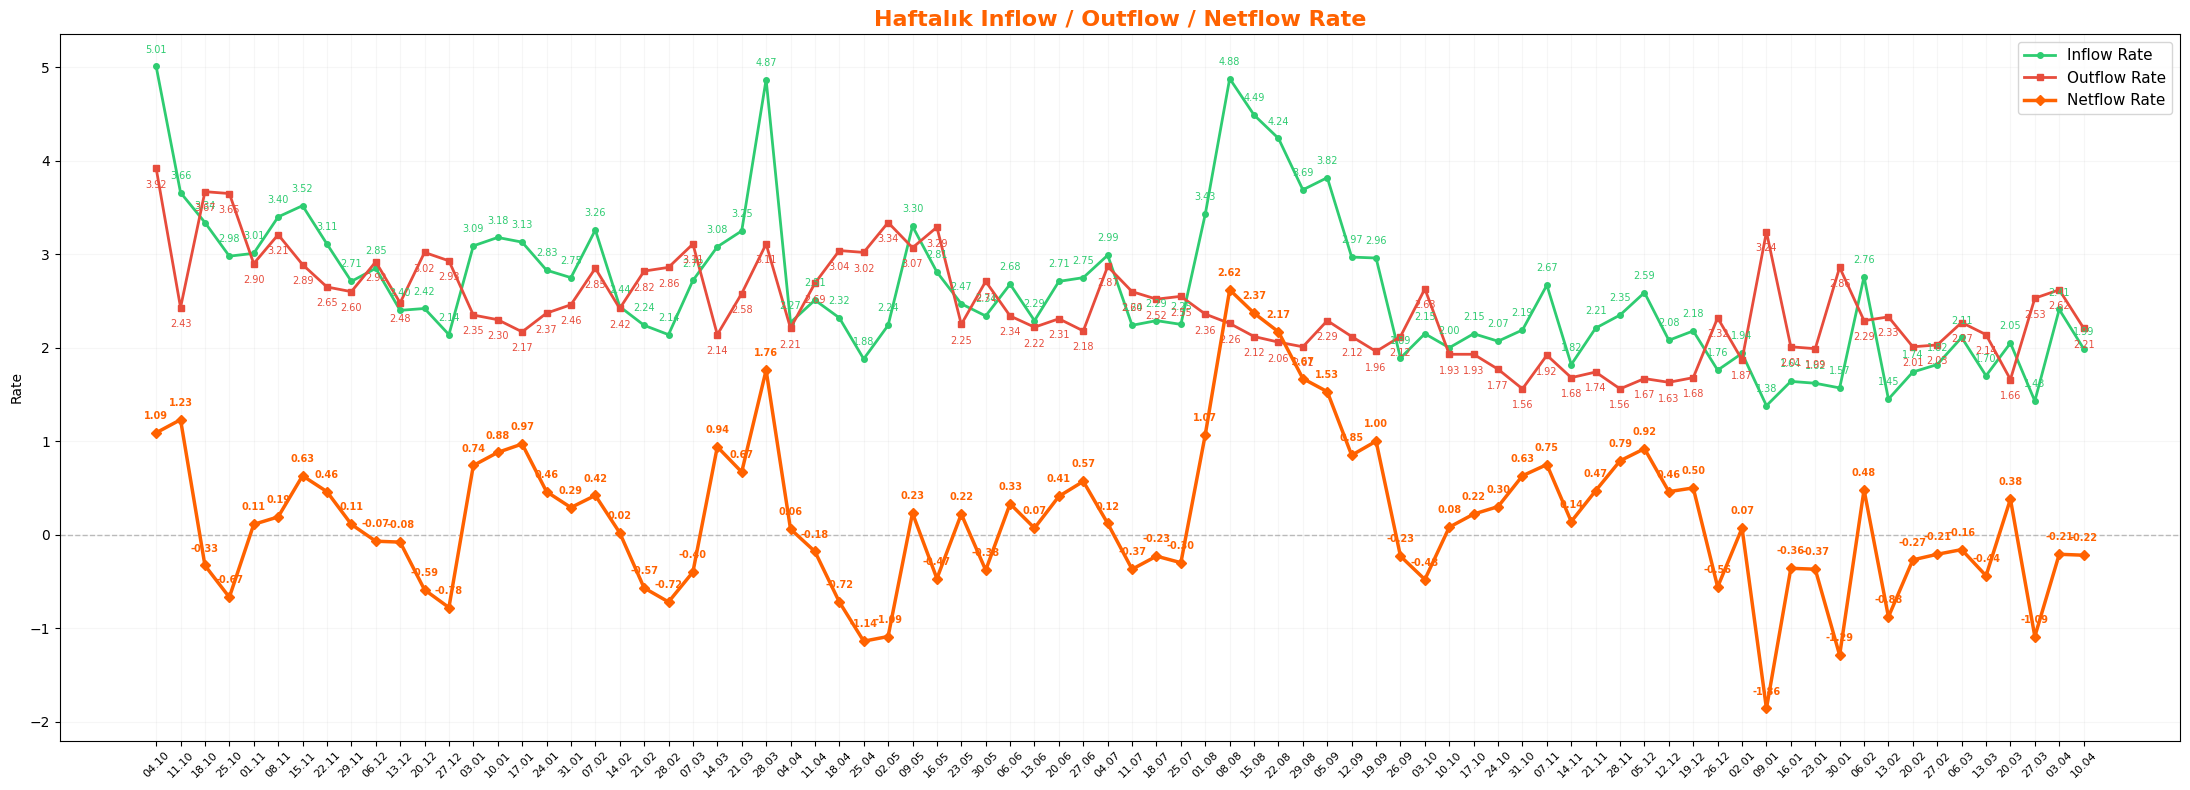

In [17]:
# 1. Veri Kaynaklarını Yükle
df_macro = pd.read_excel('FORA_MODEL.xlsx')               # Makro & piyasa verileri
df_internal = pd.read_csv('internal_dataset.csv')          # Banka iç verileri

# 1b. Seçici Round — küçük ölçekli feature'larda bilgi kaybını önle
#     Kur_Vol ort.=0.0015, PP Getiri ort.=0.005 gibi sütunlar
#     round(2) ile bilgilerini kaybeder → bu sütunlara round(6).
#     Büyük ölçekli sütunlar (TLREF ~40, VIX ~20 vs.) → round(2).
def _smart_round(frame):
    num_cols = frame.select_dtypes(include='number').columns
    for c in num_cols:
        col_mean = frame[c].abs().mean()
        if pd.isna(col_mean) or col_mean == 0:
            continue
        frame[c] = frame[c].round(2 if col_mean >= 1 else 6)
    return frame

df_macro = _smart_round(df_macro)
df_internal = _smart_round(df_internal)

# 2. Tarih Standardizasyonu
df_macro['Date'] = pd.to_datetime(df_macro['Max Tarih'], format='mixed', dayfirst=True)
df_internal['Date'] = pd.to_datetime(df_internal['max_tarih'], format='mixed', dayfirst=True)

# 2b. Cuma günü filtresi: max_tarih bugünden büyükse o satırı kaldır
today = pd.Timestamp.today().normalize()
df_internal = df_internal[df_internal['Date'] <= today].reset_index(drop=True)

# 2c. Kapanmamış hafta koruması:
#     Netflow rate Cuma kapanışında kesinleşir. internal_dataset.csv
#     Cuma günü oluşturulduğunda bile is_gunu=5 gözükür ama rate'ler
#     henüz kesinleşmemiştir (inflow=0, outflow=25 gibi saçma değerler).
#
#     Kural: "Son kapanmış Cuma" hesapla → max_tarih > bu tarih ise
#     o satırın rate kolonları NaN yapılır.
#
#     Pzt-Cum çalıştırıldığında → son kapanmış = geçen Cuma
#     Cmt-Paz çalıştırıldığında → son kapanmış = bu Cuma (zaten kapandı)
_weekday = today.weekday()  # Pzt=0 … Cum=4, Cmt=5, Paz=6
_days_since_fri = (_weekday - 4) % 7   # Cum=0, Cmt=1, Paz=2, Pzt=3 …
if _days_since_fri == 0:
    # Bugün Cuma ama henüz kapanmadı → geçen Cumayı al
    _last_closed_friday = today - pd.Timedelta(days=7)
else:
    _last_closed_friday = today - pd.Timedelta(days=_days_since_fri)

_rate_cols = ['netflow_rate', 'total_inflow_rate', 'total_outflow_rate']
_incomplete_mask = df_internal['Date'] > _last_closed_friday
if _incomplete_mask.any():
    df_internal.loc[_incomplete_mask, _rate_cols] = np.nan
    n_masked = _incomplete_mask.sum()
    print(f"Kapanmamış hafta: {n_masked} satırda rate → NaN "
          f"(max_tarih > {_last_closed_friday.strftime('%d.%m.%Y')}, "
          f"sysdate={today.strftime('%d.%m.%Y')} {['Pzt','Sal','Çar','Per','Cum','Cmt','Paz'][_weekday]})")

# 3. Veri Birleştirme
# Makro tarafından tarih ve hedef kolonları düşür (iç veriden gelecek)
cols_to_drop_macro = [c for c in ['Max Tarih', 'Min Tarih', 'netflow_rate', 'total_inflow_rate', 'total_outflow_rate'] if c in df_macro.columns]
df = pd.merge(
    df_macro.drop(columns=cols_to_drop_macro),
    df_internal,
    on='Date',
    how='outer'
).sort_values('Date').reset_index(drop=True)

# Hedef değişkeni standart isme çevir
df = df.rename(columns={'netflow_rate': 'NET'})

# Kolon sıralaması: tarih ve hedef önce
cols_front = ['Date', 'min_tarih', 'max_tarih', 'NET']
other_cols = [c for c in df.columns if c not in cols_front]
df = df[cols_front + other_cols]

# ── Train / Predict Ayrımı ────────────────────────────────────────
# Nowcast modeli: NET bilinen haftalar → eğitim, NET bilinmeyen → tahmin.
# Kapanmamış hafta(lar)ın feature'ları geçerli — sadece hedef (NET) NaN.
# Bu satırları silmek yerine df_predict olarak saklıyoruz.
#
# İki tür NET=NaN satır var:
#   1) Başlangıç haftası (kısa hafta, rate hiç hesaplanmamış) → eğitime de tahmine de girmez
#   2) Kapanmamış güncel hafta → tahmin için kullanılacak
# Ayrım: son kapanmış Cuma'dan sonraki satırlar = tahmin adayı
_predict_mask = df['NET'].isna() & df['Date'].notna() & (df['Date'] > _last_closed_friday)
df_predict = df[_predict_mask].copy()
df = df.dropna(subset=['NET']).reset_index(drop=True)

if len(df_predict) > 0:
    print(f"Tahmin Haftası ({len(df_predict)} satır) — NET henüz kesinleşmedi:")
    _pred_show = ['Date', 'min_tarih', 'max_tarih', 'NET']
    _pred_extra = ['osawelcome', 'osabook', 'TLREF', 'Benchmark', 'VIX',
                   'CDS_5Y', 'TCMB_Politika', 'is_gunu_sayisi']
    _pred_show += [c for c in _pred_extra if c in df_predict.columns]
    display(df_predict[_pred_show].style.format({
        'Date': lambda x: x.strftime('%d.%m.%Y') if pd.notna(x) else '',
        'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y') if pd.notna(x) else '',
        'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y') if pd.notna(x) else ''
    }))
    print("Bu haftanın feature'ları geçerli. Model eğitildikten sonra tahmin için kullanılacak.")
else:
    print("\nTüm haftalar kapanmış — tahmin bekleyen satır yok.")

# Kaynak Özeti
print(f"Veri Kaynakları Özeti:")
print(f"Makro Veri     : {len(df_macro)} hafta ({df_macro['Date'].min().strftime('%d.%m.%Y')} → {df_macro['Date'].max().strftime('%d.%m.%Y')})")
print(f"İç Veri        : {len(df_internal)} hafta ({df_internal['Date'].min().strftime('%d.%m.%Y')} → {df_internal['Date'].max().strftime('%d.%m.%Y')})")
print(f"Birleşik Matris: {len(df)} hafta (hedef hizalı)")

# 4. İlk ve Son Satırlar
display(df.head(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))
display(df.tail(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# 5. Birleşik Matris Detayları
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
print(f"Birleşik Matris Detayları:")
print(f"Toplam Satır   : {len(df)}")
print(f"Toplam Değişken: {len(df.columns)}")
print(f"Hedef Doluluğu : {df['NET'].notna().sum()} / {len(df)} dolu gözlem")
print(f"Başlangıç      : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"Bitiş          : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

# 6. Inflow / Outflow / Netflow Tek Grafik
fig, ax = plt.subplots(figsize=(22, 8))

dates = df['Date']

if 'total_inflow_rate' in df.columns:
    ax.plot(dates, df['total_inflow_rate'], color='#2ecc71', linewidth=2, marker='o', markersize=4, label='Inflow Rate')
    for x, y in zip(dates, df['total_inflow_rate']):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=7, color='#2ecc71', ha='center')

if 'total_outflow_rate' in df.columns:
    ax.plot(dates, df['total_outflow_rate'], color='#e74c3c', linewidth=2, marker='s', markersize=4, label='Outflow Rate')
    for x, y in zip(dates, df['total_outflow_rate']):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, -14), fontsize=7, color='#e74c3c', ha='center')

ax.plot(dates, df['NET'], color='#ff6200', linewidth=2.5, marker='D', markersize=5, label='Netflow Rate', zorder=5)
for x, y in zip(dates, df['NET']):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=7, color='#ff6200', ha='center', fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Haftalık Inflow / Outflow / Netflow Rate', fontsize=16, fontweight='bold', color='#ff6200')
ax.set_ylabel('Rate')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.1)
plt.xticks(dates, [d.strftime('%d.%m') for d in dates], rotation=45, fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

<h2 style="color: rgb(255,98,0)">Outlier Audit</h2>

Netflow Rate bir fark serisi olduğu için (Inflow − Outflow) küçük değişimler bile büyük sıçramalar yaratabilir. 
Aşağıda en uç haftalar tek tek inceleniyor: bu haftalar veri hatası mı, yoksa açıklanabilir iş olayları mı?

Amaç silmek değil, anlamak. Eğer spike'lar kampanya/faiz şoku/çeyrek sonu gibi gerçek olaylara denk geliyorsa modelde kalmalı.

**Ek Analiz — Bileşen Ayrıştırması:**
Her outlier haftada NET sıçramasının kaynağını (Inflow mu, Outflow mu, ikisi birden mi?) tespit etmek ve değerlerin "absürt" mü yoksa açıklanabilir mi olduğunu sayısal olarak doğrulamak için ek diagnostik katmanlar eklendi.

In [4]:
# BOLUM 1: NET Outlier Tespiti (IQR ve Z-Score)
Q1, Q3 = df['NET'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
z_scores = np.abs((df['NET'] - df['NET'].mean()) / df['NET'].std())

df['is_outlier_iqr'] = (df['NET'] < lower) | (df['NET'] > upper)
df['z_score'] = z_scores.round(2)

print(f"NET Dağılım Özeti:")
print(f"Ortalama : {df['NET'].mean():.4f}")
print(f"Medyan   : {df['NET'].median():.4f}")
print(f"Std      : {df['NET'].std():.4f}")
print(f"Min      : {df['NET'].min():.4f}")
print(f"Max      : {df['NET'].max():.4f}")
print(f"IQR Band : [{lower:.4f}, {upper:.4f}]")
print(f"IQR Dışı : {df['is_outlier_iqr'].sum()} hafta")
print(f"Z > 2.0  : {(z_scores > 2).sum()} hafta")
print()

audit_cols = ['Date', 'min_tarih', 'max_tarih', 'NET', 'z_score']
for col in ['total_inflow_rate', 'total_outflow_rate', 'toplam_ntb', 'opening_account', 'avg_vadeli_bakiye',
            'Payday', 'YearEnd', 'Ramazan', 'PPK_Haftasi', 'Market_Anomaly']:
    if col in df.columns:
        audit_cols.append(col)

top5 = df.nlargest(5, 'NET')[audit_cols]
bot5 = df.nsmallest(5, 'NET')[audit_cols]

print("En Yüksek 5 Netflow Haftası:")
display(top5.style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

print("\nEn Düşük 5 Netflow Haftası:")
display(bot5.style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# BOLUM 2: Bilesen Ayristirmasi — Kaynak Tespiti (Inflow mu, Outflow mu?)
inflow_mean, inflow_std = df['total_inflow_rate'].mean(), df['total_inflow_rate'].std()
outflow_mean, outflow_std = df['total_outflow_rate'].mean(), df['total_outflow_rate'].std()

df['inflow_z'] = ((df['total_inflow_rate'] - inflow_mean) / inflow_std).round(2)
df['outflow_z'] = ((df['total_outflow_rate'] - outflow_mean) / outflow_std).round(2)

df['inflow_pctl'] = df['total_inflow_rate'].rank(pct=True).round(2)
df['outflow_pctl'] = df['total_outflow_rate'].rank(pct=True).round(2)

def dominant_driver(row):
    inf_z = abs(row['inflow_z'])
    out_z = abs(row['outflow_z'])
    if inf_z > 1.5 and out_z > 1.5:
        return 'Ikisi Birden'
    elif inf_z > out_z:
        return 'Inflow Kaynakli'
    else:
        return 'Outflow Kaynakli'

df['dominant_driver'] = df.apply(dominant_driver, axis=1)

def absurdity_check(row):
    inf_p, out_p = row['inflow_pctl'], row['outflow_pctl']
    if (inf_p <= 0.10 and out_p >= 0.90) or (inf_p >= 0.90 and out_p <= 0.10):
        return 'Absurt (Iki Yonlu Anomali)'
    elif inf_p <= 0.10 or inf_p >= 0.90 or out_p <= 0.10 or out_p >= 0.90:
        return 'Tek Kanal Anomali'
    else:
        return 'Normal Bant Ici'

df['absurdity'] = df.apply(absurdity_check, axis=1)

# Gecikmeli etkinlik flag'leri
event_flags = ['Payday', 'YearEnd', 'Ramazan', 'PPK_Haftasi', 'Market_Anomaly']
for flag in event_flags:
    if flag in df.columns:
        df[f'{flag}_lag1'] = df[flag].shift(1).fillna(0).astype(int)

def model_risk(row):
    is_outlier = row['is_outlier_iqr']
    absurd = row['absurdity']

    has_event = any([row.get('Payday', 0), row.get('YearEnd', 0), row.get('Ramazan', 0),
                     row.get('PPK_Haftasi', 0), row.get('Market_Anomaly', 0)])
    has_lagged_event = any([row.get('Payday_lag1', 0), row.get('YearEnd_lag1', 0),
                            row.get('Ramazan_lag1', 0), row.get('PPK_Haftasi_lag1', 0),
                            row.get('Market_Anomaly_lag1', 0)])
    has_any_event = has_event or has_lagged_event

    if not is_outlier:
        return 'Normal'
    elif absurd == 'Absurt (Iki Yonlu Anomali)' and not has_any_event:
        return 'DIKKAT — Absurt + Aciklama Yok'
    elif absurd == 'Absurt (Iki Yonlu Anomali)' and has_lagged_event and not has_event:
        return 'Kabul — Gecikmeli Etkinlik (Hangover)'
    elif absurd == 'Absurt (Iki Yonlu Anomali)' and has_event:
        return 'Kabul — Absurt Ama Etkinlik Var'
    elif has_event:
        return 'Kabul — Etkinlik Aciklamali'
    elif has_lagged_event:
        return 'Kabul — Gecikmeli Etkinlik'
    else:
        return 'Kabul — Organik Trend'

df['model_risk'] = df.apply(model_risk, axis=1)

# Outlier Haftalarin Ayristirma Tablosu
decomp_cols = ['Date', 'min_tarih', 'max_tarih', 'NET',
               'total_inflow_rate', 'inflow_z', 'inflow_pctl',
               'total_outflow_rate', 'outflow_z', 'outflow_pctl',
               'dominant_driver', 'absurdity', 'model_risk']

outlier_decomp = df[df['is_outlier_iqr']].sort_values('NET', ascending=False)[decomp_cols]

print(f"\nBileşen Ayrıştırması:")
print(f"Inflow  ort: {inflow_mean:.2f}  std: {inflow_std:.2f}")
print(f"Outflow ort: {outflow_mean:.2f}  std: {outflow_std:.2f}")
print()

if len(outlier_decomp) > 0:
    display(outlier_decomp.style.format({
        'Date': lambda x: x.strftime('%d.%m.%Y'),
        'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
        'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
        'inflow_z': '{:+.2f}', 'outflow_z': '{:+.2f}',
        'inflow_pctl': '{:.0%}', 'outflow_pctl': '{:.0%}'
    }).applymap(lambda v: 'background-color: #ffe0e0' if v == 'DIKKAT — Absurt + Aciklama Yok'
                else ('background-color: #e0ffe0' if 'Kabul' in str(v) else ''),
                subset=['model_risk']))
else:
    print("IQR dışı outlier hafta bulunmadı.")

# BOLUM 3: Gorsellestirme (4 Panel)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel 1: NET Histogram + IQR sinirlari
axes[0, 0].hist(df['NET'], bins=15, alpha=0.7, color='#ff6200', edgecolor='white')
axes[0, 0].axvline(lower, color='#e74c3c', linestyle='--', linewidth=2, label=f'IQR Alt: {lower:.2f}')
axes[0, 0].axvline(upper, color='#e74c3c', linestyle='--', linewidth=2, label=f'IQR Ust: {upper:.2f}')
axes[0, 0].axvline(df['NET'].median(), color='#1f77b4', linestyle='-', linewidth=2, label=f'Medyan: {df["NET"].median():.2f}')
axes[0, 0].set_title('Netflow Rate Dagilimi', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.1)

# Panel 2: Zaman serisi + outlier isaretleme
outlier_mask = df['is_outlier_iqr']
axes[0, 1].plot(df['Date'], df['NET'], color='#ff6200', linewidth=1.5, alpha=0.7)
axes[0, 1].scatter(df.loc[outlier_mask, 'Date'], df.loc[outlier_mask, 'NET'],
                color='#e74c3c', s=80, zorder=5, edgecolors='white', linewidth=1.5, label='IQR Disi')
axes[0, 1].axhline(upper, color='#e74c3c', linestyle='--', alpha=0.5)
axes[0, 1].axhline(lower, color='#e74c3c', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Netflow Zaman Serisi — Outlier Isaretli', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.1)

# Panel 3: Inflow vs Outflow Scatter
colors = ['#e74c3c' if o else '#cccccc' for o in df['is_outlier_iqr']]
sizes = [120 if o else 30 for o in df['is_outlier_iqr']]
axes[1, 0].scatter(df['total_inflow_rate'], df['total_outflow_rate'], c=colors, s=sizes,
                   alpha=0.7, edgecolors='white', linewidth=0.5, zorder=3)
axes[1, 0].axvline(df['total_inflow_rate'].median(), color='#2ecc71', linestyle='--', alpha=0.5, label=f'Inflow Med: {df["total_inflow_rate"].median():.2f}')
axes[1, 0].axhline(df['total_outflow_rate'].median(), color='#e74c3c', linestyle='--', alpha=0.5, label=f'Outflow Med: {df["total_outflow_rate"].median():.2f}')
for _, row in df[df['is_outlier_iqr']].iterrows():
    axes[1, 0].annotate(f'NET:{row["NET"]:.1f}',
                        (row['total_inflow_rate'], row['total_outflow_rate']),
                        textcoords='offset points', xytext=(8, 8), fontsize=8,
                        fontweight='bold', color='#e74c3c')
axes[1, 0].set_xlabel('Total Inflow Rate', fontsize=11)
axes[1, 0].set_ylabel('Total Outflow Rate', fontsize=11)
axes[1, 0].set_title('Inflow vs Outflow — Outlier Kaynagi', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.1)

# Panel 4: Outlier Haftalarin Bilesen Z-Score Karsilastirmasi
outlier_df = df[df['is_outlier_iqr']].sort_values('NET', ascending=False).copy()
if len(outlier_df) > 0:
    x_pos = np.arange(len(outlier_df))
    width = 0.35
    bars1 = axes[1, 1].bar(x_pos - width/2, outlier_df['inflow_z'], width,
                           label='Inflow Z-Score', color='#2ecc71', alpha=0.8, edgecolor='white')
    bars2 = axes[1, 1].bar(x_pos + width/2, outlier_df['outflow_z'], width,
                           label='Outflow Z-Score', color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([f'NET:{r["NET"]:.1f}\n{r["Date"].strftime("%d.%m")}' for _, r in outlier_df.iterrows()],
                               fontsize=8)
    axes[1, 1].axhline(0, color='gray', linestyle='-', linewidth=0.5)
    axes[1, 1].axhline(1.5, color='#e74c3c', linestyle=':', alpha=0.4, label='Anormallik Esigi (+/-1.5)')
    axes[1, 1].axhline(-1.5, color='#e74c3c', linestyle=':', alpha=0.4)
    for bar in bars1:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{bar.get_height():+.1f}', ha='center', va='bottom', fontsize=7, color='#2ecc71')
    for bar in bars2:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{bar.get_height():+.1f}', ha='center', va='bottom', fontsize=7, color='#e74c3c')
axes[1, 1].set_title('Outlier Bilesen Ayristirmasi (Z-Score)', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.1)

fig.suptitle('Outlier Audit', fontsize=16, fontweight='bold', color='#ff6200', y=1.01)
fig.tight_layout()
plt.close(fig)

# BOLUM 4: Sonuc Ozeti
n_outlier = df['is_outlier_iqr'].sum()
n_absurd = (df['absurdity'] == 'Absurt (Iki Yonlu Anomali)').sum()
n_risky = (df['model_risk'] == 'DIKKAT — Absurt + Aciklama Yok').sum()

absurd_weeks = df[df['absurdity'] == 'Absurt (Iki Yonlu Anomali)'][['Date', 'NET', 'model_risk']].copy()

print(f"\nOutlier Sonuç:")
print(f"IQR dışı hafta       : {n_outlier} / {len(df)}")
print(f"Çift kanal anomali   : {n_absurd}")
print(f"Açıklanamayan        : {n_risky}")

if n_absurd > 0:
    print(f"\nÇift kanal detay:")
    for _, r in absurd_weeks.iterrows():
        print(f"{r['Date'].strftime('%d.%m.%Y')}  NET={r['NET']:.2f}  {r['model_risk']}")

print()
if n_risky == 0:
    print("Karar: Modele alınabilir.")
    if n_absurd > 0:
        print(f"Not: {n_absurd} çift kanal anomali gecikmeli etkinlik etkisiyle açıklanıyor.")
else:
    print(f"Uyarı: {n_risky} hafta açıklanamıyor, veri kalitesi kontrol edilmeli.")

# Temizlik: gecici kolonlari kaldir
lag_cols = [f'{f}_lag1' for f in event_flags if f'{f}_lag1' in df.columns]
df = df.drop(columns=['is_outlier_iqr', 'z_score', 'inflow_z', 'outflow_z',
                       'inflow_pctl', 'outflow_pctl', 'dominant_driver',
                       'absurdity', 'model_risk'] + lag_cols)

NET Dağılım Özeti:
Ortalama : 0.1727
Medyan   : 0.1100
Std      : 0.8098
Min      : -1.8600
Max      : 2.6200
IQR Band : [-1.8125, 2.0475]
IQR Dışı : 4 hafta
Z > 2.0  : 4 hafta

En Yüksek 5 Netflow Haftası:


,Date,min_tarih,max_tarih,NET,z_score,total_inflow_rate,total_outflow_rate,toplam_ntb,opening_account,avg_vadeli_bakiye,Payday,YearEnd,Ramazan,PPK_Haftasi,Market_Anomaly
43,08.08.2025,04.08.2025,08.08.2025,2.620000,3.020000,4.880000,2.260000,617.000000,2553.000000,37898.240000,0,0,0,0,0
44,15.08.2025,11.08.2025,15.08.2025,2.370000,2.710000,4.490000,2.120000,687.000000,2821.000000,42291.950000,1,0,0,0,0
45,22.08.2025,18.08.2025,22.08.2025,2.170000,2.470000,4.240000,2.060000,819.000000,3077.000000,47664.600000,0,0,0,0,0
24,28.03.2025,24.03.2025,28.03.2025,1.760000,1.960000,4.870000,3.110000,582.000000,2452.000000,37511.110000,0,0,1,0,1
46,29.08.2025,25.08.2025,29.08.2025,1.670000,1.850000,3.690000,2.010000,819.000000,3017.000000,52163.500000,0,0,0,0,0



En Düşük 5 Netflow Haftası:


,Date,min_tarih,max_tarih,NET,z_score,total_inflow_rate,total_outflow_rate,toplam_ntb,opening_account,avg_vadeli_bakiye,Payday,YearEnd,Ramazan,PPK_Haftasi,Market_Anomaly
65,09.01.2026,05.01.2026,09.01.2026,-1.860000,2.510000,1.380000,3.240000,375.000000,1502.000000,71714.310000,0,0,0,0,0
68,30.01.2026,26.01.2026,30.01.2026,-1.290000,1.810000,1.570000,2.860000,379.000000,1789.000000,64462.420000,0,0,0,0,0
28,25.04.2025,21.04.2025,25.04.2025,-1.140000,1.620000,1.880000,3.020000,256.000000,1133.000000,36217.610000,0,0,0,0,1
29,02.05.2025,28.04.2025,02.05.2025,-1.090000,1.560000,2.240000,3.340000,223.000000,1235.000000,34488.420000,1,0,0,0,0
76,27.03.2026,23.03.2026,27.03.2026,-1.090000,1.560000,1.430000,2.530000,263.000000,1486.000000,56961.450000,0,0,0,0,0



Bileşen Ayrıştırması:
Inflow  ort: 2.60  std: 0.74
Outflow ort: 2.42  std: 0.49



,Date,min_tarih,max_tarih,NET,total_inflow_rate,inflow_z,inflow_pctl,total_outflow_rate,outflow_z,outflow_pctl,dominant_driver,absurdity,model_risk
43,08.08.2025,04.08.2025,08.08.2025,2.620000,4.880000,+3.07,100%,2.260000,-0.33,41%,Inflow Kaynakli,Tek Kanal Anomali,Kabul — Gecikmeli Etkinlik
44,15.08.2025,11.08.2025,15.08.2025,2.370000,4.490000,+2.54,97%,2.120000,-0.61,28%,Inflow Kaynakli,Tek Kanal Anomali,Kabul — Etkinlik Aciklamali
45,22.08.2025,18.08.2025,22.08.2025,2.170000,4.240000,+2.21,96%,2.060000,-0.74,25%,Inflow Kaynakli,Tek Kanal Anomali,Kabul — Gecikmeli Etkinlik
65,09.01.2026,05.01.2026,09.01.2026,-1.860000,1.380000,-1.63,1%,3.240000,+1.65,95%,Ikisi Birden,Absurt (Iki Yonlu Anomali),Kabul — Gecikmeli Etkinlik (Hangover)



Outlier Sonuç:
IQR dışı hafta       : 4 / 79
Çift kanal anomali   : 1
Açıklanamayan        : 0

Çift kanal detay:
09.01.2026  NET=-1.86  Kabul — Gecikmeli Etkinlik (Hangover)

Karar: Modele alınabilir.
Not: 1 çift kanal anomali gecikmeli etkinlik etkisiyle açıklanıyor.


<h2 style="color: rgb(255,98,0)">Türetilmiş Değişkenler (Feature Engineering)</h2>

Bu adımda faiz dönüşümleri ve taktik spread hesaplamaları yapılarak ürünün piyasa benchmark'larına göre 
göreli çekiciliği ölçülür.

In [5]:
# Bileşik / Basit faiz dönüşümleri
df["TLREF_Bilesik"] = ((1 + df["TLREF"] / 100) ** (365/365) - 1) * 100  # TLREF'i bileşik faize çevir
df["TCMB_1M_Basit"] = ((1 + df["TCMB 1M"] / 100) ** (30/365) - 1) / (30/365) * 100
df["TCMB_3M_Basit"] = ((1 + df["TCMB 3M"] / 100) ** (90/365) - 1) / (90/365) * 100

# OSA welcome yıllıklandırılmış faiz (basit → bileşik)
df["osawelcomeannual"] = ((1 + df["osawelcome"] / 100 * 32/365) ** (365/32) - 1) * 100
df["osawelcomewcurrent"] = ((1 + df["osawelcomeannualwcurrent"] / 100) ** (32/365) - 1) * (365/32) * 100

# Spread hesaplamaları: ürün faizinin piyasa benchmark'larına göreli konumu
df["w/TLREF"] = df["osawelcomeannual"] - df["TLREF_Bilesik"]       # Welcome vs TLREF farkı
df["w/1month"] = df["osawelcomeannual"] - df["TCMB 1M"]            # Welcome vs TCMB 1 aylık farkı
df["w/3month"] = df["osawelcomeannual"] - df["TCMB 3M"]            # Welcome vs TCMB 3 aylık farkı

# Piyasa benchmark'ına göre nominal fark
df["osawelcome-benchmark"] = df["osawelcome"] - df["Benchmark"]

# Mevcut müşteri welcome spread'leri (delta bazlı)
df["w/TLREF(deltas)"] = df["osawelcomeannualwcurrent"] - df["TLREF_Bilesik"]
df["w/1month(deltas)"] = df["osawelcomeannualwcurrent"] - df["TCMB 1M"]
df["w/3month(deltas)"] = df["osawelcomeannualwcurrent"] - df["TCMB 3M"]

# TCMB basit faiz vs TLREF spread'leri
df["<1month-TLREF"] = df["TCMB_1M_Basit"] - df["TLREF"]
df["<3month-TLREF"] = df["TCMB_3M_Basit"] - df["TLREF"]

# İlk ve son satırlar
display(df.head(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))
display(df.tail(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# Matris Detayları
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
print(f"Matris Detayları:")
print(f"  Toplam Satır   : {len(df)}")
print(f"  Toplam Değişken: {len(df.columns)}")
print(f"  Hedef Doluluğu : {df['NET'].notna().sum()} / {len(df)} dolu gözlem")
print(f"  Başlangıç      : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"  Bitiş          : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,TLREF_Bilesik,TCMB_1M_Basit,TCMB_3M_Basit,osawelcomewcurrent,w/TLREF,w/1month,w/3month,osawelcome-benchmark,w/TLREF(deltas),w/1month(deltas),w/3month(deltas),<1month-TLREF,<3month-TLREF
0,11.10.2024,07.10.2024,11.10.2024,1.230000,49.650720,50.000000,0.005310,54.460000,59.190000,nan,9009.830000,60.030000,2.880000,35.767750,1,nan,50.000000,2628.800000,21.262000,13016.060000,1.096100,34.248800,37.530300,4.424500,31.010000,78.626000,102.780000,9009.772100,0.000589,2894.630000,0.017494,74.900000,80.550000,3480131652,104.070000,71.710000,167.600000,1.387900,27.440000,3.120000,8.800000,77,74,278.220000,2.880000,82.441800,74.139700,82.378400,78.945800,83.190100,81.126200,79.678300,19989.250000,97406.110000,89826.080000,51756.890000,0,0,0,4,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0.196900,49.940000,48.590620,nan,54.800000,0.029200,4.809300,1.257600,-2.146700,-0.682400,0.144700,-0.356400,1170.885800,0.531400,1137.819600,649.573200,1.016217,0.913881,0.957594,0.965049,0,0,0,0,0,9.106182,7.970958,54.800000,54.840000,nan,50.000000,50.000000,nan,0.218000,2.837400,nan,-6.835400,0.876200,nan,0.200700,0.293600,nan,1.281700,1.079200,nan,4.860000,6.249400,nan,279.810000,281.410000,nan,18.918000,15.804000,nan,50.000000,50.000000,nan,27.450000,27.490000,nan,3.134000,3.190000,nan,48.962900,1.038700,-2.702000,3.885700,0.791000,1.828500,0.001200,0.000400,0.213000,0.075200,280.610000,2.057800,-0.289300,-0.340000,0.000000,-1.590000,0.000000,48.330000,62.080000,44.120000,31187.870000,2976.23

,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,TLREF_Bilesik,TCMB_1M_Basit,TCMB_3M_Basit,osawelcomewcurrent,w/TLREF,w/1month,w/3month,osawelcome-benchmark,w/TLREF(deltas),w/1month(deltas),w/3month(deltas),<1month-TLREF,<3month-TLREF
74,13.03.2026,09.03.2026,13.03.2026,-0.440000,39.992760,40.000000,0.003400,44.320000,45.240000,42.000000,13091.430000,51.490000,2.479500,47.236550,1,38.484500,37.000000,5131.380000,25.828000,17224.400400,1.156300,44.107000,51.045500,5.817800,84.752800,96.468000,99.468000,13091.420100,0.000970,7276.610000,0.020533,73.300000,85.040000,4566101223,110.700000,58.660000,159.100000,1.188500,22.170000,3.840000,9.000000,36,34,259.280000,2.479500,130.204200,126.920800,124.523000,119.681800,101.880300,122.779500,121.404300,33072.810000,118699.400000,125211.190000,90274.240000,0,0,0,2,3,0,0,0,1,0,0,0,0,0,1,0,0,0,0.787800,39.949000,36.829520,36.840360,44.280000,0.038800,4.327200,0.853200,0.556700,0.019500,0.318400,-0.340600,1165.086900,0.760500,1046.200800,743.583500,1.060472,1.033730,0.919185,1.047101,0,0,0,0,0,9.479789,8.892558,44.280000,42.970000,43.430000,39.260000,37.000000,37.000000,-0.698200,4.633700,3.571000,-6.363800,-1.482300,1.877100,0.230200,0.265100,0.215100,0.849600,-0.119000,-0.118100,4.331000,6.140500,6.589600,242.360000,226.370000,214.100000,23.880000,19.396000,18.844000,37.000000,37.000000,37.000000,22.170000,22.100000,22.100000,3.840000,3.900000,3.900000,38.377000,1.841000,-1.542800,3.402700,0.887200,2.515000,0.001000,0.000100,0.284300,0.044700,236.637500,18.058900

Matris Detayları:
  Toplam Satır   : 79
  Toplam Değişken: 187
  Hedef Doluluğu : 79 / 79 dolu gözlem
  Başlangıç      : 07.10.2024 – 11.10.2024
  Bitiş          : 06.04.2026 – 10.04.2026


<h2 style="color: rgb(255,98,0)">Eksik Veri Yönetimi (NaN)</h2>

Zaman serisi yapısına uygun şekilde eksik değerler ileri/geri doldurma (forward/backward fill) ile tamamlanır. 
Modelin her hafta tutarlı bir feature seti görmesi sağlanır.

In [6]:
# ── Aylık/çeyreklik makro göstergeleri ffill ──
# Pipeline (build_model_dataset) zaten ffill yapıyor ama notebook'ta
# ilk 3 satır düştüğü için bazı kolonların başı hâlâ NaN olabilir.
# Sadece bilinen aylık/çeyreklik seriler — haftalık seriler veya
# binary flag'ler buraya dahil DEĞİL (onlara ffill anlamsız).
macro_ffill = [
    'KKO', 'Tuketici_Guven', 'Net_Rezerv', 'Sanayi_Uretim',
    'Ihtiyac_Kredi_Faizi', 'Fin_Guven', 'Cekirdek_Enflasyon',
    'Enflasyon_Beklenti_12ay', 'GSYH_Buyume_Beklenti', 'Issizlik',
    'WebTufe_TUFE_Aylik',
    'WebTufe_Gida_Endeks', 'WebTufe_Enerji_Endeks',
    'WebTufe_Ulastirma_Endeks', 'WebTufe_Hizmet_Endeks',
    'WebTufe_Giyim_Endeks', 'WebTufe_Endeks',
    'WebTufe_KisiselBakim_Endeks', 'WebTufe_Aclik_Siniri',
    'BKM_Giyim_TL', 'BKM_Yemek_TL', 'BKM_Kozmetik_TL',
    'WebTufe'
]
macro_ffill = [c for c in macro_ffill if c in df.columns]
df[macro_ffill] = df[macro_ffill].ffill()

# Reel Faiz: TLREF yıllık, WebTüfe aylık → yıllığa çevirip fark al (ffill sonrası)
df['Reel_Faiz'] = (df['TLREF'] - df['WebTufe'] * 12).round(4)
for lag in [1, 2, 4]:
    df[f'Reel_Faiz_lag{lag}'] = df['Reel_Faiz'].shift(lag)

# ── Benchmark: boş haftaları TLREF + medyan spread ile doldur ──
mask_bm = df['Benchmark'].notna()
spread = (df.loc[mask_bm, 'Benchmark'] - df.loc[mask_bm, 'TLREF']).median()
df['Benchmark'] = df['Benchmark'].fillna(df['TLREF'] + spread)
df['osawelcome-benchmark'] = df['osawelcome'] - df['Benchmark']

# ── Benchmark_All: Benchmark ile arasındaki oran üzerinden doldur ──
if 'Benchmark_All' in df.columns:
    mask_both = df['Benchmark_All'].notna() & df['Benchmark'].notna()
    if mask_both.sum() >= 2:
        avg_ratio = (df.loc[mask_both, 'Benchmark_All'] / df.loc[mask_both, 'Benchmark']).mean()
        df['Benchmark_All'] = df['Benchmark_All'].fillna(df['Benchmark'] * avg_ratio)
        print(f"Benchmark_All Oran : {avg_ratio:.4f}  ({mask_both.sum()} gözlemden)")
    else:
        df = df.drop(columns=['Benchmark_All'])
        print("Benchmark_All      : yeterli veri yok, düşürüldü")

# ── Kur_Vol: ortadaki tek NaN → interpolasyon ──
if 'Kur_Vol' in df.columns:
    df['Kur_Vol'] = df['Kur_Vol'].interpolate()
if 'TLREF_x_KurVol' in df.columns and 'Kur_Vol' in df.columns:
    df['TLREF_x_KurVol'] = df['TLREF'] * df['Kur_Vol']

# ── BIST_Vol: ortadaki NaN'lar → interpolasyon ──
if 'BIST_Vol' in df.columns and df['BIST_Vol'].isna().any():
    df['BIST_Vol'] = df['BIST_Vol'].interpolate()

# ── Blanket ffill/bfill YOK ──
# Kalan NaN'lar Cell 15'te halledilir:
#   - >50% NaN olan kolonlar düşürülür
#   - Kalan NaN satırları dropna ile çıkarılır
# Binary flag'ler (Kur_Spike, Altin_Rush vb.) ve
# haftalık getiri kolonları (BIST100_Getiri, Altin_Getiri vb.)
# geriye taşınmaz — ilk satırdaki NaN doğaldır (pct_change/diff).

# ── Eksik Veri Yönetimi Özeti ──
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
nan_count = df.isna().sum().sum()
nan_cols = df.columns[df.isna().any()].tolist()
print(f"Eksik Veri Yönetimi Özeti:")
print(f"Benchmark Spread : {spread:.4f}")
print(f"Toplam Satır     : {len(df)}")
print(f"Toplam Değişken  : {len(df.columns)}")
print(f"Kalan NaN        : {nan_count}  ({len(nan_cols)} kolonda)")
print(f"Başlangıç        : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"Bitiş            : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

if nan_cols:
    print(f"\nNaN Detay (kolon bazında):")
    for c in nan_cols:
        n = df[c].isna().sum()
        first_nan = df.index[df[c].isna()][0]
        print(f"  {c:<40s}  {n:3d} NaN  (ilk NaN: satır {first_nan})")

# Haftalık Süreklilik Kontrolü
diff_series = df['Date'].diff().dt.days
diffs = diff_series.dropna()
gaps = df[diff_series > 8]

if len(gaps) == 0:
    print(f"\nSüreklilik       : Boşluk yok - her hafta mevcut (tüm farklar {int(diffs.min())} gün)")
else:
    print(f"\n{len(gaps)} haftalık boşluk tespit edildi:")
    for idx in gaps.index:
        prev = df.loc[idx-1, 'Date'].strftime('%d.%m.%Y')
        curr = df.loc[idx, 'Date'].strftime('%d.%m.%Y')
        print(f"    {prev} → {curr} ({int(diff_series.loc[idx])} gün)")

print("\nGün Sayısı Kontrol:")
check_df = pd.DataFrame({
    'Önceki Tarih': df['Date'].shift(1).dt.strftime('%d.%m.%Y'),
    'Mevcut Tarih': df['Date'].dt.strftime('%d.%m.%Y'),
    'Gün Farkı': diff_series
}).dropna()
irregular = check_df[check_df['Gün Farkı'] != 7]
if len(irregular) > 0:
    print(f"{len(irregular)} düzensiz aralık tespit edildi:")
    display(irregular.style.format({'Gün Farkı': '{:.0f}'}))
else:
    print("Tüm aralıklar 7 gün — düzensizlik yok.")

Benchmark_All Oran : 0.9124  (67 gözlemden)
Eksik Veri Yönetimi Özeti:
Benchmark Spread : 4.0682
Toplam Satır     : 79
Toplam Değişken  : 187
Kalan NaN        : 22  (15 kolonda)
Başlangıç        : 07.10.2024 – 11.10.2024
Bitiş            : 06.04.2026 – 10.04.2026

NaN Detay (kolon bazında):
  TLREF_lag4                                  1 NaN  (ilk NaN: satır 0)
  TCMB_1M_lag4                                1 NaN  (ilk NaN: satır 0)
  AOFF_lag4                                   1 NaN  (ilk NaN: satır 0)
  Altin_Getiri_lag4                           2 NaN  (ilk NaN: satır 0)
  BIST100_Getiri_lag4                         2 NaN  (ilk NaN: satır 0)
  Kur_Degisim_lag4                            2 NaN  (ilk NaN: satır 0)
  Reel_Faiz_lag1                              1 NaN  (ilk NaN: satır 0)
  Reel_Faiz_lag2                              2 NaN  (ilk NaN: satır 0)
  Reel_Faiz_lag4                              4 NaN  (ilk NaN: satır 0)
  Faiz_Spread_lag4                            1 NaN  (ilk Na

<h2 style="color: rgb(255,98,0)">Etkileşim Değişkenleri (İç × Dış Çaprazlama)</h2>

Banka iç metrikleri ile makroekonomik göstergelerin çapraz çarpımından türetilen etkileşim değişkenleri. 
Tek başına zayıf olan sinyallerin birleşiminden daha güçlü tahmin gücü elde edilmesi hedeflenir.

In [7]:
# NOWCAST ZAMANLAMA KATMANI
# Model Pazartesi çalışır. İş birimi 3 girdi sağlar: osawelcome, osaftp, TLREF
# TCMB 1M/3M/Politika iş birimi bilir (CBRT avg) → T'de kalır
# Takvim flag'leri önceden bilinir → T'de kalır
# Geri kalan her şey → shift(1) ile T-1'e çekilir

KNOWN_AT_T = {
    # Meta + Target
    'Date', 'min_tarih', 'max_tarih', 'NET',
    # İş Birimi Girdileri (Pazartesi sabahı girilir)
    'osawelcome', 'osaftp', 'TLREF',
    # Girdilerden türetilen (Cell 11)
    'TLREF_Bilesik', 'osawelcomeannual',
    'TCMB_1M_Basit', 'TCMB_3M_Basit',
    'w/TLREF', 'w/1month', 'w/3month',
    '<1month-TLREF', '<3month-TLREF',
    # TCMB faizleri (inherently T-1, iş birimi CBRT avg olarak bilir)
    'TCMB 1M', 'TCMB 3M', 'TCMB_Politika',
    'Faiz_Spread',
    # KNOWN kaynaklı lag/rolling/delta (FORA_MODEL.xlsx)
    'TLREF_lag1', 'TLREF_lag2', 'TLREF_lag4',
    'TCMB_1M_lag1', 'TCMB_1M_lag2', 'TCMB_1M_lag4',
    'TCMB_Politika_lag1', 'TCMB_Politika_lag2', 'TCMB_Politika_lag4',
    'Faiz_Spread_lag1', 'Faiz_Spread_lag2', 'Faiz_Spread_lag4',
    'w/TLREF_lag1', 'w/TLREF_lag2', 'w/TLREF_lag4',
    'TLREF_roll4_mean', 'TLREF_roll4_std',
    'TLREF_delta1', 'TCMB_1M_delta1', 'TCMB_Politika_delta1',
    # Takvim / Binary Flag'ler (önceden bilinir)
    'Payday', 'YearEnd', 'PPK_Haftasi', 'Ramazan', 'Market_Anomaly',
    'Bayram_Haftasi', 'Quarter_End', 'Tax_Season', 'Temetu_Donemi',
    'Full_Workday', 'Black_Friday', 'School_Vacation',
    'Asgari_Ucret_Zam', 'Holiday_Cash', 'Turizm_Sezonu',
    "Sonraki PPK'ya Gun", "Sonraki PPK'ya Gün", 'Sonraki_PPK_Gun',
}

shift_cols = [c for c in df.select_dtypes(include=[np.number]).columns
              if c not in KNOWN_AT_T]
n_shifted = len(shift_cols)

for col in shift_cols:
    df[col] = df[col].shift(1)

# Shift sonrası ilk satır NaN → doldur
df = df.ffill().bfill()

# osawelcome-benchmark yeniden hesapla: mevcut welcome(T) vs geçen hafta rekabet(T-1)
df['osawelcome-benchmark'] = df['osawelcome'] - df['Benchmark']

print(f"Nowcast Zamanlama Uygulandı:")
print(f"T'de bilinen    : {len([c for c in KNOWN_AT_T if c in df.columns])} kolon")
print(f"T-1'e shift     : {n_shifted} kolon")
print()

# Rekabetçi Faiz × Hacim
df['competitive_x_ntb'] = df['osawelcome-benchmark'] * df['toplam_ntb']           # Benchmark farkı × yeni müşteri
df['competitive_x_opening'] = df['osawelcome-benchmark'] * df['opening_account']   # Benchmark farkı × hesap açılış

# Maliyet Spread'i × Piyasa Stresi
df['vdeli_spread_x_vix'] = df['avg_vdeli_spread'] * df['VIX']             # Vadeli spread × küresel korku
df['vdesiz_spread_x_cds'] = df['avg_vdesiz_dahil_spread'] * df['CDS_5Y']  # Vadesiz dahil spread × ülke riski

# Bakiye İvmesi × Faiz Ortamı
df['vadeli_x_reel_faiz'] = df['avg_vadeli_bakiye'] * df['Reel_Faiz']      # Vadeli bakiye × reel faiz

# Müşteri Davranış Oranları
df['ntb_ratio'] = df['toplam_ntb'] / df['opening_account'].replace(0, np.nan)
df['ntb_ratio'] = df['ntb_ratio'].fillna(0)
df['maliyet_x_welcome'] = df['maliyet_hosgeldin_orani'] * df['osawelcome']

# Çapraz Alan Oranları
df['welcome_tlref_ratio'] = df['osawelcome'] / df['TLREF_Bilesik'].replace(0, np.nan)
df['welcome_tlref_ratio'] = df['welcome_tlref_ratio'].fillna(0)

# Alternatif Yatırım Rekabeti
df['welcome_vs_gold'] = df['osawelcomeannual'] - df['Altin_Getiri'] * 52
df['welcome_vs_bist'] = df['osawelcomeannual'] - df['BIST100_Getiri'] * 52

# Mevduat Yapısal Karışımı
df['vadesiz_vadeli_ratio'] = df['avg_vadesiz_bakiye'] / df['avg_vadeli_bakiye'].replace(0, np.nan)
df['vadesiz_vadeli_ratio'] = df['vadesiz_vadeli_ratio'].fillna(0)
df['vadeli_concentration'] = df['avg_vadeli_bakiye'] / df['avg_th_total'].replace(0, np.nan)
df['vadeli_concentration'] = df['vadeli_concentration'].fillna(0)

# FTP Kârlılık vs Piyasa
df['ftp_vs_tlref'] = df['osaftp'] - df['TLREF']

# Kur Stresi × Bakiye
df['kur_x_vadeli'] = df['Kur_Degisim'] * df['avg_vadeli_bakiye']

# Günlük Operasyonel Verimlilik
df['daily_acquisition'] = (df['toplam_ntb'] + df['toplam_existing']) / df['is_gunu_sayisi']

# Bileşen Akış Sinyalleri (Nowcast: total_inflow/outflow zaten T-1'e shift edildi)
# current_week kaldırıldı — nowcast'te bu haftanın akışı bilinmez
df['inflow_lag1'] = df['total_inflow_rate'].round(2)                                # T-1 (shift sonrası)
df['inflow_lag2'] = df['total_inflow_rate'].shift(1).fillna(0).round(2)             # T-2
df['inflow_roll3'] = df['total_inflow_rate'].rolling(3).mean().fillna(0).round(2)   # T-1,T-2,T-3 ort

df['outflow_lag1'] = df['total_outflow_rate'].round(2)                              # T-1
df['outflow_lag2'] = df['total_outflow_rate'].shift(1).fillna(0).round(2)           # T-2
df['outflow_roll3'] = df['total_outflow_rate'].rolling(3).mean().fillna(0).round(2) # T-1,T-2,T-3 ort

# İç İvme (Haftalık Değişim)
df['welcome_delta'] = df['osawelcome'].diff().fillna(0)                    # Welcome faiz haftalık değişim
df['vadeli_bakiye_delta'] = df['avg_vadeli_bakiye'].pct_change().fillna(0) # Vadeli bakiye yüzdesel değişim
df['ntb_delta'] = df['toplam_ntb'].diff().fillna(0)                        # NTB haftalık fark

# Fiyatlama Agresifliği: Welcome vs Book farkı
df['welcome_book_gap'] = df['osawelcome'] - df['osabook_basit']

# Takvim × Rekabetçi Konum
df['competitive_x_payday'] = df['osawelcome-benchmark'] * df['Payday']

# Piyasa Stres Bileşik Skoru
df['stress_composite'] = df['Market_Stress'] * df['VIX'] * df['CDS_5Y']

# Maliyet Ağırlıklı Bakiye
df['cost_weighted_balance'] = df['avg_vadeli_bakiye'] * df['toplam_cof_basit']

# İleri Düzey İç x Dış Çaprazlamalar (Internal x External)
# 1. Makro Stres ve Likidite Makasları
df['kur_vol_x_vadesiz'] = df['Kur_Vol'] * df['avg_vadesiz_bakiye']
df['welcome_vs_bist_vol'] = df['osawelcome'] * df['BIST_Vol']
df['kredi_mevduat_makasi'] = df['Ihtiyac_Kredi_Faizi'] - df['osawelcomeannual']

# 2. Davranışsal Makro Çaprazlamalar
df['welcome_delta_x_guven'] = df['welcome_delta'] * df['Tuketici_Guven']
df['bakiye_x_enflasyon_bekl'] = df['avg_th_total'] * df['Enflasyon_Beklenti_12ay']

# 3. Takvim × Müşteri Edinimi / Agresiflik
df['ntb_x_yearend'] = df['toplam_ntb'] * df['YearEnd']
df['ntb_x_payday'] = df['toplam_ntb'] * df['Payday']
df['ppk_x_welcome_delta'] = df['PPK_Haftasi'] * df['welcome_delta']

# 4. Makro Bağlam Çaprazlamaları (External x External)
df['kur_enflasyon_sarmali'] = df['Kur_Degisim'] * df['Enflasyon_Beklenti_12ay']
df['reel_faiz_x_guven'] = df['Reel_Faiz'] * df['Tuketici_Guven']

# 5. Bileşik Takvimsel Basınç (Calendar Compounding)
calendar_cols = ['Payday', 'YearEnd', 'Ramazan', 'PPK_Haftasi',
                 'Bayram_Haftasi', 'Quarter_End', 'Tax_Season', 'Temetu_Donemi']
calendar_cols = [c for c in calendar_cols if c in df.columns]
df['calendar_pressure_score'] = df[calendar_cols].sum(axis=1)
df['is_event_week'] = (df['calendar_pressure_score'] > 0).astype(int)

# 6. Etkinlik Haftasında Müşteri/Faiz İvmesi
df['event_week_x_ntb'] = df['is_event_week'] * df['toplam_ntb']
df['event_week_x_welcome'] = df['is_event_week'] * df['welcome_delta']

# 7. Tüketici Davranışı ve Harcama/Tasarruf İştahı
df['payday_x_reel_faiz'] = df['Payday'] * df['Reel_Faiz']
df['vadesiz_x_enflasyon'] = df['avg_vadesiz_bakiye'] * df['Enflasyon_Beklenti_12ay']
df['sefalet_endeksi_proxy'] = df['Issizlik'] + df['Enflasyon_Beklenti_12ay']

# 8. Birleşik Alternatif Piyasa Fırsat Maliyeti
df['alt_piyasa_baskisi'] = (df['Altin_Getiri'] * 52 + df['BIST100_Getiri'] * 52) - df['osawelcomeannual']

# 9. Kredi Daralması ve Mevduat Yığılması
df['kredi_faiz_x_ntb'] = df['Ihtiyac_Kredi_Faizi'] * df['toplam_ntb']

# 10. Tüketim Çılgınlığı ve Kredi Kartı Ödeme Baskısı
if all(c in df.columns for c in ['BKM_Giyim_TL', 'BKM_Yemek_TL', 'BKM_Kozmetik_TL']):
    df['bkm_toplam_harcama'] = df['BKM_Giyim_TL'] + df['BKM_Yemek_TL'] + df['BKM_Kozmetik_TL']
    df['harcama_tehdidi_vadesiz'] = df['bkm_toplam_harcama'] / df['avg_vadesiz_bakiye'].replace(0, np.nan)

# 11. Reel Sektör İşlem Hacmi
df['kko_x_sanayi'] = df['KKO'] * df['Sanayi_Uretim']

# 12. Sistemik Likidite Stresi
df['aoff_tlref_makasi'] = df['AOFF'] - df['TLREF']
df['kur_rezerv_kalkani'] = df['Net_Rezerv'] / df['Kur_Vol'].replace(0, np.nan)

# 13. Zorunlu Harcama Etkisi
df['gida_enflasyon_baskisi'] = df['WebTufe_Gida_Endeks'] * df['Enflasyon_Beklenti_12ay']

# 14. Hedefe Yönelik Özel Makro Sinyaller
if 'USD_TRY' in df.columns and 'EUR_TRY' in df.columns:
    df['sepet_kur_05_05'] = (df['USD_TRY'] * 0.5) + (df['EUR_TRY'] * 0.5)
    df['sepet_kur_degisim'] = df['sepet_kur_05_05'].pct_change().fillna(0)
    df['sepet_kur_x_vadesiz'] = df['sepet_kur_degisim'] * df['avg_vadesiz_bakiye']
df['makro_panik_endeksi'] = (df['CDS_5Y'] * df['Kur_Vol']) / df['Tuketici_Guven'].replace(0, np.nan)
df['kko_arz_soku_baskisi'] = df['Enflasyon_Beklenti_12ay'] / df['KKO'].replace(0, np.nan)
df['buyume_vs_tahvil'] = df['GSYH_Buyume_Beklenti'] - df['Benchmark']
df['mtm_guvenli_liman_kaos'] = df['BIST_Vol'] * df['Altin_Getiri'].abs()

# 15. Dinamik İş Sinyalleri
df['tcmb_1m_delta'] = df['TCMB 1M'].diff().fillna(0)
df['relative_pricing_momentum'] = df['welcome_delta'] - df['tcmb_1m_delta']
df['vadesiz_bakiye_delta'] = df['avg_vadesiz_bakiye'].pct_change().fillna(0)
df['ic_gecis_hareketi'] = df['vadeli_bakiye_delta'] - df['vadesiz_bakiye_delta']
df['welcome_ntb_verimi'] = df['toplam_ntb'] / df['osawelcome'].replace(0, np.nan)

# Etkinlik Sonrası Çıkış Riski (Hangover)
df['post_yearend_hangover'] = df['YearEnd'].shift(1).fillna(0)
df['post_payday_hangover'] = df['Payday'].shift(1).fillna(0)
df['post_ramazan_hangover'] = df['Ramazan'].shift(1).fillna(0)
for col_name in ['Bayram_Haftasi', 'Quarter_End', 'Tax_Season', 'Black_Friday', 'School_Vacation', 'Temetu_Donemi']:
    if col_name in df.columns:
        df[f'post_{col_name.lower()}_hangover'] = df[col_name].shift(1).fillna(0)

# Anlık Kredi Şoku
df['kredi_faiz_soku'] = df['Ihtiyac_Kredi_Faizi'].diff().fillna(0)

# 16. Bilanço Derinliği
df['ticket_size_bakiye'] = df['avg_vadeli_bakiye'] / df['opening_account'].replace(0, np.nan)
df['carry_trade_cazibesi'] = df['TLREF_Bilesik'] - (df['Kur_Degisim'] * 52)

# 17. Eksik Ham Sinyaller
if 'GT_Mevduat_Faizi' in df.columns:
    df['gt_mevduat_lag1'] = df['GT_Mevduat_Faizi'].shift(1).fillna(0)
    df['gt_mevduat_delta'] = df['GT_Mevduat_Faizi'].diff().fillna(0)
    df['gt_mevduat_x_welcome'] = df['GT_Mevduat_Faizi'] * df['osawelcome']
if 'GT_En_Yuksek' in df.columns:
    df['gt_en_yuksek_lag1'] = df['GT_En_Yuksek'].shift(1).fillna(0)

if 'TCMB_Politika_delta1' in df.columns:
    df['ppk_siddet_x_ntb'] = df['TCMB_Politika_delta1'] * df['toplam_ntb']
    df['ppk_siddet_x_welcome'] = df['TCMB_Politika_delta1'] * df['welcome_delta']

if 'Likidite_Sikisma' in df.columns:
    df['likidite_x_vadesiz'] = df['Likidite_Sikisma'] * df['avg_vadesiz_bakiye']
if 'Zorunlu_Harcama_Baskisi' in df.columns:
    df['zorunlu_harcama_x_bakiye'] = df['Zorunlu_Harcama_Baskisi'] * df['avg_th_total']

spike_cols = ['CDS_Spike', 'Kur_Spike', 'Enflasyon_Sok', 'Altin_Rush', 'Faiz_Anomaly']
for sc in spike_cols:
    if sc in df.columns:
        df[f'{sc.lower()}_x_ntb'] = df[sc] * df['toplam_ntb']

if 'Faiz_Spread' in df.columns:
    df['faiz_spread_x_vadeli'] = df['Faiz_Spread'] * df['avg_vadeli_bakiye']
    df['faiz_spread_x_welcome'] = df['Faiz_Spread'] * df['osawelcome']

if 'Fin_Guven' in df.columns:
    df['fin_guven_x_ntb'] = df['Fin_Guven'] * df['toplam_ntb']
    df['fin_guven_x_vadeli'] = df['Fin_Guven'] * df['avg_vadeli_bakiye']

if 'XBANK' in df.columns:
    df['xbank_delta'] = df['XBANK'].pct_change().fillna(0)
    df['xbank_x_vadesiz'] = df['xbank_delta'] * df['avg_vadesiz_bakiye']

if 'Brent' in df.columns:
    df['brent_delta'] = df['Brent'].pct_change().fillna(0)
    df['brent_x_kur'] = df['brent_delta'] * df['Kur_Degisim']

if 'DXY' in df.columns:
    df['dxy_delta'] = df['DXY'].pct_change().fillna(0)
    df['dxy_x_vadesiz'] = df['dxy_delta'] * df['avg_vadesiz_bakiye']

if 'Spot Kredi' in df.columns:
    df['spot_kredi_x_welcome'] = df['Spot Kredi'] * df['osawelcome']

if 'avg_vadeli_tl' in df.columns and 'avg_vadeli_bakiye' in df.columns:
    df['tl_yogunlasma_orani'] = df['avg_vadeli_tl'] / df['avg_vadeli_bakiye'].replace(0, np.nan)
    df['tl_yogunlasma_orani'] = df['tl_yogunlasma_orani'].fillna(0)
    df['tl_yogunlasma_x_kur'] = df['tl_yogunlasma_orani'] * df['Kur_Degisim']

df['welcome_vol_3w'] = df['osawelcome'].rolling(3).std().fillna(0)
df['flow_momentum_gap'] = df['inflow_roll3'] - df['outflow_roll3']

if 'Asgari_Ucret_Zam' in df.columns:
    df['asgari_ucret_x_ntb'] = df['Asgari_Ucret_Zam'] * df['toplam_ntb']
if 'Holiday_Cash' in df.columns:
    df['holiday_cash_x_vadesiz'] = df['Holiday_Cash'] * df['avg_vadesiz_bakiye']
if 'Turizm_Sezonu' in df.columns:
    df['turizm_x_kur'] = df['Turizm_Sezonu'] * df['Kur_Degisim']

# Otoregresif Sinyaller (Netflow momentum)
df['NET_lag1'] = df['NET'].shift(1).fillna(0)
df['NET_lag2'] = df['NET'].shift(2).fillna(0)
df['NET_roll3'] = df['NET'].rolling(3).mean().fillna(0).round(2)

# Netflow İkinci Türevi
df['netflow_hiz_ivmesi'] = df['NET_lag1'] - df['NET_lag2']

# Marj Sıkışması
df['ftp_delta'] = df['osaftp'].diff().fillna(0)
df['margin_squeeze'] = df['ftp_delta'] - df['welcome_delta']

# Nowcast Hedef: NET doğrudan bu haftanın netflow'u (shift yok)
# Train: X = T'deki bilinen + T-1 shift edilmiş feature'lar, y = NET(T)
# Prediction: İş birimi osawelcome/osaftp/TLREF girer, geri kalan T-1'den gelir
df_model = df.copy()

# Nowcast Matris Özeti
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
nan_count = df.isna().sum().sum()
print(f"Nowcast Matris Özeti:")
print(f"Toplam Satır     : {len(df)}")
print(f"Toplam Değişken  : {len(df.columns)}")
print(f"Kalan NaN        : {nan_count}")
print(f"Başlangıç        : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"Bitiş            : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")
print(f"Model Satırı     : {len(df_model)}")

print("\nNowcast Doğrulaması (Son 5 Satır):")
cols_to_show = ['min_tarih', 'max_tarih', 'NET',
                'NET_lag1', 'NET_lag2', 'NET_roll3',
                'inflow_lag1', 'inflow_lag2', 'inflow_roll3',
                'outflow_lag1', 'outflow_lag2', 'outflow_roll3']
display(df_model[cols_to_show].tail(5))

Nowcast Zamanlama Uygulandı:
T'de bilinen    : 51 kolon
T-1'e shift     : 136 kolon

Nowcast Matris Özeti:
Toplam Satır     : 79
Toplam Değişken  : 301
Kalan NaN        : 0
Başlangıç        : 07.10.2024 – 11.10.2024
Bitiş            : 06.04.2026 – 10.04.2026
Model Satırı     : 79

Nowcast Doğrulaması (Son 5 Satır):


,min_tarih,max_tarih,NET,NET_lag1,NET_lag2,NET_roll3,inflow_lag1,inflow_lag2,inflow_roll3,outflow_lag1,outflow_lag2,outflow_roll3
74,2026-03-09,2026-03-13,-0.44,-0.16,-0.21,-0.27,2.11,1.82,1.89,2.27,2.03,2.10
75,2026-03-16,2026-03-20,0.38,-0.44,-0.16,-0.07,1.70,2.11,1.88,2.14,2.27,2.15
76,2026-03-23,2026-03-27,-1.09,0.38,-0.44,-0.38,2.05,1.70,1.95,1.66,2.14,2.02
77,2026-03-30,2026-04-03,-0.21,-1.09,0.38,-0.31,1.43,2.05,1.73,2.53,1.66,2.11
78,2026-04-06,2026-04-10,-0.22,-0.21,-1.09,-0.51,2.41,1.43,1.96,2.62,2.53,2.27
